# **PyTorch Basics Tutorial**

The following tutorial is adapted from the [DeepLearningForNLPInPytorch tutorial](https://github.com/rguthrie3/DeepLearningForNLPInPytorch/blob/master/Deep%20Learning%20for%20Natural%20Language%20Processing%20with%20Pytorch.ipynb) and the [Official PyTorch tutorials](https://pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html#sphx-glr-beginner-blitz-tensor-tutorial-py).

## Installation

**Via Anaconda/Miniconda:**  
`condainstall pytorch-c pytorch`

**Via pip:**  
`pip3 install torch`


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.10.0+cpu


In [3]:
torch.cuda.is_available()

False

## 1. Tensors
Tensors are similar to NumPy’s ndarrays, with the addition being that Tensors can also be used on a GPU to accelerate computing.

### 1.1 Creating Tensors from data
Tensors can be created from Python lists with the `torch.Tensor()` function.

In [6]:
# Example with 1-D data
data = [1.0, 2.0, 3.0]
tensor = torch.Tensor(data)
print("Example with 1-D data")
print(tensor)

# Example with 2-D data
data = [[1., 2., 3.], [4., 5., 6]]
tensor = torch.Tensor(data)
print("\nExample with 2-D data")
print(tensor)

# Example with 3-D data
data = [[[1.,2.], [3.,4.]],
        [[5.,6.], [7.,8.]]]
tensor = torch.Tensor(data)
print("\nExample with 3-D data")
print(tensor)

Example with 1-D data
tensor([1., 2., 3.])

Example with 2-D data
tensor([[1., 2., 3.],
        [4., 5., 6.]])

Example with 3-D data
tensor([[[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]]])


In [8]:
tensor.shape

torch.Size([2, 2, 2])

### 1.2 Initializing an empty Tensor
An uninitialized matrix is declared, but does not contain definite known values before it is used. When an uninitialized matrix is created, whatever values were in the allocated memory at the time will appear as the initial values.


In [4]:
# Construct a 2x3 matrix, uninitialized
x = torch.empty(2, 3)
print(x)

tensor([[2.0213e-34, 0.0000e+00, 2.4816e-34],
        [0.0000e+00, 4.4842e-44, 0.0000e+00]])


### 1.3 Randomly initialized Tensor



In [5]:
x = torch.rand(2, 3)
print(x)

tensor([[0.9703, 0.7865, 0.7958],
        [0.8763, 0.0329, 0.7644]])


### 1.4 Tensor with zeros or ones

In [6]:
# Create a matrix of all zeros
x = torch.zeros(2, 3)
print("Matrix of zeros")
print(x)

# Create a matrix of all zeros and explicitly set data type to be long int
x = torch.zeros(2, 3, dtype=torch.long)
print("\nMatrix of zeros typecasted to long")
print(x)

x = torch.ones(2, 3, dtype=torch.long)
print("\nMatrix of ones typecasted to long")
print(x)


Matrix of zeros
tensor([[0., 0., 0.],
        [0., 0., 0.]])

Matrix of zeros typecasted to long
tensor([[0, 0, 0],
        [0, 0, 0]])

Matrix of ones typecasted to long
tensor([[1, 1, 1],
        [1, 1, 1]])


### 1.5 Create Tensor based on existing Tensor

In [7]:
x = x.new_ones(2, 3, dtype=torch.double)      # new_* methods take in sizes
print(x)

x = torch.randn_like(x, dtype=torch.float)    # override dtype!
print(x)                                      # result has the same size

tensor([[1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)
tensor([[-0.1751, -0.4821,  0.7401],
        [ 0.8071, -0.2718, -0.8807]])


### 1.6 Size of a Tensor
`torch.Size` is in fact a tuple, so it supports all tuple operations.

In [8]:
# Example with 1-D data
data = [1.0, 2.0, 3.0]
tensor = torch.Tensor(data)
print("Example with 1-D data")
print(tensor)
print(tensor.size())

# Example with 2-D data
data = [[1., 2., 3.], [4., 5., 6]]
tensor = torch.Tensor(data)
print("\nExample with 2-D data")
print(tensor)
print(tensor.size())

# Example with 3-D data
data = [[[1.,2.], [3.,4.]],
        [[5.,6.], [7.,8.]]]
tensor = torch.Tensor(data)
print("\nExample with 3-D data")
print(tensor)
print(tensor.size())

Example with 1-D data
tensor([1., 2., 3.])
torch.Size([3])

Example with 2-D data
tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])

Example with 3-D data
tensor([[[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]]])
torch.Size([2, 2, 2])


### 1.7 Operations with Tensors
Most operations are very similar to NumPy.

In [10]:
# Addition
x = torch.Tensor([ 1., 2., 3. ])
y = torch.Tensor([ 4., 5., 6. ])

# using arithmetic operation
z = x + y
print(z)

# using method
print(torch.add(x, y))

tensor([5., 7., 9.])
tensor([5., 7., 9.])


In [11]:
# In-place addition

x = torch.Tensor([ 1., 2., 3. ])
y = torch.Tensor([ 4., 5., 6. ])

y.add_(x)
print(y)

tensor([5., 7., 9.])


Any operation that mutates a tensor in-place is post-fixed with an underscore `_`. For example: `x.copy_(y)`, `x.t_()`, will change `x`.

See [the PyTorch official documentation](http://pytorch.org/docs/torch.html) for a complete list of the massive number of operations available to you.  They expand beyond just mathematical operations.


In [13]:
# Indexing

x = torch.Tensor([  [1., 2., 3.],
                    [4., 5., 6]   ])
print(x[:, 1]) # Gets column with index 1

tensor([2., 5.])


### 1.8 Reshaping Tensors

In [14]:
x = torch.randn(4, 4)
y = x.view(16)
z = x.view(-1, 8)  # the size -1 is inferred from other dimensions
print(x.size(), y.size(), z.size())

torch.Size([4, 4]) torch.Size([16]) torch.Size([2, 8])


In [15]:
x = torch.randn(1)
print(x)
print(x.item())

tensor([-0.4679])
-0.4678862690925598


### 1.9 Converting to and from NumPy
Converting a Torch Tensor to a NumPy array and vice versa is a breeze.

The Torch Tensor and NumPy array will **share their underlying memory locations** (if the Torch Tensor is on CPU), and **changing one will change the other**.



In [16]:
a = torch.ones(5)
print("Original a:", a)

b = a.numpy()
print("Original b:", b)

a.add_(1)
print("New a:", a)
print("New b:", b)

Original a: tensor([1., 1., 1., 1., 1.])
Original b: [1. 1. 1. 1. 1.]
New a: tensor([2., 2., 2., 2., 2.])
New b: [2. 2. 2. 2. 2.]


In [17]:
import numpy as np
a = np.ones(5)
b = torch.from_numpy(a)
np.add(a, 1, out=a)
print(a)
print(b)

[2. 2. 2. 2. 2.]
tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


### 1.10. CUDA Tensors

Tensors can be moved onto any device using the `.to` method.


### Enable GPU on your Colab notebook

Go to Edit -> Notebook Settings -> select GPU as Hardware accelerator

<img src="https://jovianlin.io/content/images/2018/01/Screen-Shot-2018-01-23-at-8.38.04-AM.png" width="300">

In [18]:
# Try to run this cell with both GPU support and without
import torch
print("CUDA available?", torch.cuda.is_available())

# We will use ``torch.device`` objects to move tensors in and out of GPU
if torch.cuda.is_available():
    device = torch.device("cuda")          # a CUDA device object
    x = torch.Tensor([1.0, 2.0, 3.0])
    y = torch.ones_like(x, device=device)  # directly create a tensor on GPU
    x = x.to(device)                       # or just use strings ``.to("cuda")``
    z = x + y
    print(z)
    print(z.to("cpu", torch.double))       # ``.to`` can also change dtype together!

CUDA available? False


## 2. Autograd: Automatic Differentiation

The autograd package provides automatic differentiation for all operations on Tensors. It is a define-by-run framework, which means that your backprop is defined by how your code is run, and that every single iteration can be different.

``torch.Tensor`` is the central class of the package. If you set its attribute
``.requires_grad`` as ``True``, it **starts to track all operations on it**. When
you finish your computation you can call ``.backward()`` and have **all the
gradients computed automatically**. The gradient for this tensor will be
accumulated into ``.grad`` attribute.

To **stop a tensor from tracking history**, you can call ``.detach()`` to detach
it from the computation history, and to prevent future computation from being
tracked.

To **prevent tracking history (and using memory)**, you can also wrap the code block
in ``with torch.no_grad():``. This can be particularly helpful when evaluating a
model because the model may have trainable parameters with `requires_grad=True`,
but for which we don't need the gradients.

In [19]:
import torch
x = torch.ones(2, 2, requires_grad=True)
print(x)

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)


In [20]:
y = x + 2
print(y)

# y was created as a result of an operation, so it has a grad_fn.

tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)


In [21]:
z = y * y * 3
out = z.mean()

print(z, out)

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>) tensor(27., grad_fn=<MeanBackward0>)


``.requires_grad_( ... )`` changes an existing Tensor's ``requires_grad``
flag in-place. The input flag defaults to ``False`` if not given.



In [22]:
a = torch.randn(2, 2)
a = ((a * 3) / (a - 1))
print(a.requires_grad)
a.requires_grad_(True)
print(a.requires_grad)
b = (a * a).sum()
print(b.grad_fn)

False
True


Let us consider a complete example now.

Let $out = \frac{1}{4}\sum_i z_i$,  
$z_i = 3(x_i+2)^2$  
and $z_i\bigr\rvert_{x_i=1} = 27$.  
Therefore,  
$\frac{\partial out}{\partial x_i} = \frac{1}{4}\frac{\partial z_i}{\partial x_i} = \frac{1}{4}.3.2(x_i+2) = \frac{3}{2}(x_i+2)$,  
 hence  
$\frac{\partial out}{\partial x_i}\bigr\rvert_{x_i=1} = \frac{9}{2} = 4.5$.



In [23]:
x = torch.ones(2, 2, requires_grad=True)
z = 3 * ((x + 2) ** 2)
out = z.mean()

out.backward()
print(x.grad)


tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


Mathematically, if you have a vector valued function $\vec{y}=f(\vec{x})$, then the gradient of $\vec{y}$ with respect to $\vec{x}$ is a Jacobian matrix:
\begin{split}J=\left(\begin{array}{ccc}
 \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{1}}{\partial x_{n}}\\
 \vdots & \ddots & \vdots\\
 \frac{\partial y_{m}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
 \end{array}\right)\end{split}

Generally speaking, `torch.autograd` is an engine for computing vector-Jacobian product. That is, given any vector $v=\left(\begin{array}{cccc} v_{1} & v_{2} & \cdots & v_{m}\end{array}\right)^{T}$, compute the product $v^{T}\cdot J$. If $v$ happens to be the gradient of a scalar function $l=g\left(\vec{y}\right)$, that is, $v=\left(\begin{array}{ccc}\frac{\partial l}{\partial y_{1}} & \cdots & \frac{\partial l}{\partial y_{m}}\end{array}\right)^{T}$, then by the chain rule, the vector-Jacobian product would be the gradient of $l$ with respect to $\vec{x}$:
\begin{split}J^{T}\cdot v=\left(\begin{array}{ccc}
 \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{1}}\\
 \vdots & \ddots & \vdots\\
 \frac{\partial y_{1}}{\partial x_{n}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
 \end{array}\right)\left(\begin{array}{c}
 \frac{\partial l}{\partial y_{1}}\\
 \vdots\\
 \frac{\partial l}{\partial y_{m}}
 \end{array}\right)=\left(\begin{array}{c}
 \frac{\partial l}{\partial x_{1}}\\
 \vdots\\
 \frac{\partial l}{\partial x_{n}}
 \end{array}\right)\end{split}

(Note that $v^{T}\cdot J$ gives a row vector which can be treated as a column vector by taking $J^{T}\cdot v$.)

This characteristic of vector-Jacobian product makes it very convenient to feed external gradients into a model that has non-scalar output.

You can also stop autograd from tracking history on Tensors with `.requires_grad=True` either by wrapping the code block in with `torch.no_grad()`:

In [24]:
print(x.requires_grad)
print((x ** 2).requires_grad)

with torch.no_grad():
    print((x ** 2).requires_grad)

True
True
False


Every time a variable is back propogated through, the gradient will be accumulated instead of being replaced. Calling `tensor.grad_zero()` would reset the gradients that have accumulated to 0.


# **Practice with Tensors and Neural Nets in Pytorch (nn.Module)**

Let's train a simple CNN model in pytorch using the FashionMNIST dataset

## **Import Libraries**

This code imports the necessary libraries for building and training the CNN model:

 - torch: The core PyTorch library.
 - torch.nn: Provides neural network modules and building blocks.
 - torch.nn.functional: Contains activation functions and other utility functions.
 - torch.optim: Includes optimization algorithms like SGD, Adam, etc.
 - torchvision: Provides datasets, transformations, and utilities for computer vision tasks.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

## **Load the dataset**

This code downloads the FashionMNIST dataset and creates data loaders for both training and testing.

In [ ]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.45MB/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 136kB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 2.50MB/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 7.88MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



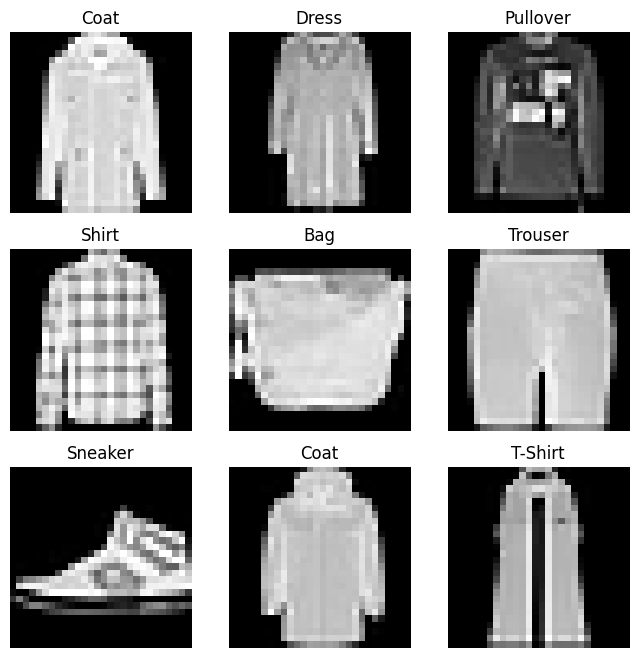

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


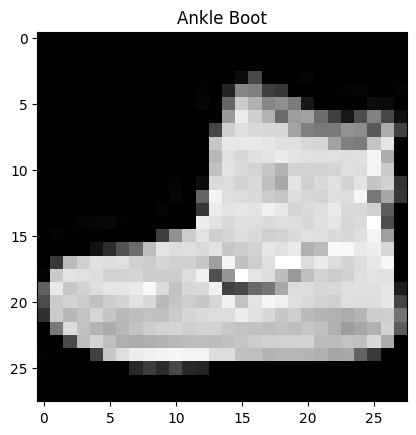

In [ ]:
# Iterate and visualize the dataset
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}


# Iterate over DATASET
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# Iterate and visualize DATALOADER
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.title(labels_map[label.item()])
plt.show()

## **Define the Model**

This code defines the CNN model architecture, which consists of two convolutional layers, two dropout layers, and two fully connected layers.

In [ ]:
# Define model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
##########################################################################################################
##########################################################################################################

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolutional Layer 1:
        #   - in_channels=1: Input channels (1 for grayscale images)
        #   - out_channels=32: Number of output filters (32 filters)
        #   - kernel_size=3: Size of the convolutional kernel (3x3)
        #   - stride=1: Stride of the convolution (moves 1 pixel at a time)
        self.conv1 = nn.Conv2d(1, 32, 3, 1)

        # Convolutional Layer 2:
        #   - in_channels=32: Input channels (output from conv1)
        #   - out_channels=64: Number of output filters (64 filters)
        #   - kernel_size=3: Size of the convolutional kernel (3x3)
        #   - stride=1: Stride of the convolution (moves 1 pixel at a time)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)

        # Dropout Layer 1:
        #   - p=0.25: Probability of an element to be zeroed (25% dropout rate)
        self.dropout1 = nn.Dropout(0.25)

        # Dropout Layer 2:
        #   - p=0.5: Probability of an element to be zeroed (50% dropout rate)
        self.dropout2 = nn.Dropout(0.5)

        # Fully Connected Layer 1:
        #   - in_features=9216: Number of input features (calculated from previous layer's output)
        #   - out_features=128: Number of output features (128 neurons)
        self.fc1 = nn.Linear(9216, 128)

        # Fully Connected Layer 2:
        #   - in_features=128: Number of input features (output from fc1)
        #   - out_features=10: Number of output features (10 classes for classification)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2) # kernel_size=2 for max pooling
        x = self.dropout1(x)
        x = torch.flatten(x, 1) # flatten starting from dimension 1
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1) # apply log_softmax along dimension 1
        return output

## **Train the model**

This code trains the model using the Adam optimizer. It iterates over the training data for a specified number of epochs and updates the model's parameters based on the calculated loss.

In [ ]:
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"


model = MLP().to(device)

# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Training loop
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

# Test loop
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

# Execute training and testing
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)

print("Done!")

Epoch 1
-------------------------------
loss: 2.302646  [   64/60000]
loss: 0.565613  [ 6464/60000]
loss: 0.389385  [12864/60000]
loss: 0.506892  [19264/60000]
loss: 0.472492  [25664/60000]
loss: 0.456126  [32064/60000]
loss: 0.373396  [38464/60000]
loss: 0.505386  [44864/60000]
loss: 0.464837  [51264/60000]
loss: 0.540940  [57664/60000]
Test Error: 
 Accuracy: 84.8%, Avg loss: 0.416433 

Epoch 2
-------------------------------
loss: 0.254064  [   64/60000]
loss: 0.345952  [ 6464/60000]
loss: 0.283318  [12864/60000]
loss: 0.371997  [19264/60000]
loss: 0.443131  [25664/60000]
loss: 0.388948  [32064/60000]
loss: 0.320587  [38464/60000]
loss: 0.460723  [44864/60000]
loss: 0.388996  [51264/60000]
loss: 0.443448  [57664/60000]
Test Error: 
 Accuracy: 85.5%, Avg loss: 0.395468 

Epoch 3
-------------------------------
loss: 0.215535  [   64/60000]
loss: 0.338937  [ 6464/60000]
loss: 0.235780  [12864/60000]
loss: 0.298572  [19264/60000]
loss: 0.459715  [25664/60000]
loss: 0.341045  [32064/600

## **Evaluate the model**

This code evaluates the trained model on the test data and prints the average loss and accuracy.

Predicted labels: ['Ankle Boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker']
Actual labels:    ['Ankle Boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker']


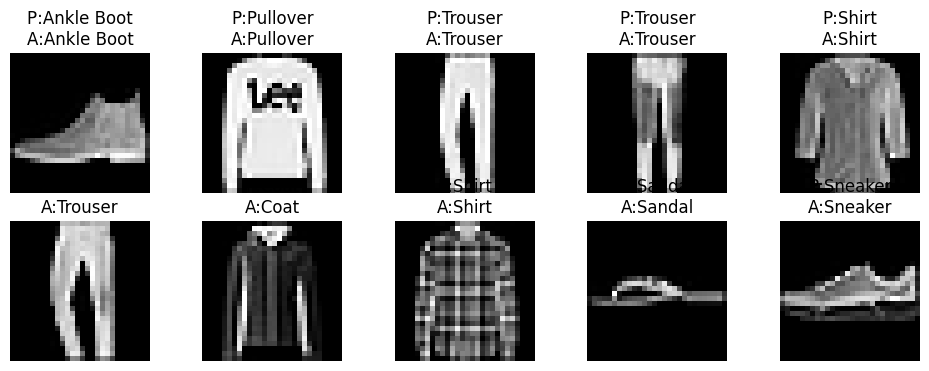

In [ ]:
model.eval()
x, y = next(iter(test_dataloader))
x, y = x.to(device), y.to(device)
with torch.no_grad():
    pred = model(x)
predicted, actual = pred.argmax(1), y

print("Predicted labels:", [labels_map[int(p)] for p in predicted[:10]])
print("Actual labels:   ", [labels_map[int(a)] for a in actual[:10]])

figure = plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.axis('off')
    plt.imshow(x[i].cpu().squeeze(), cmap='gray')
    plt.title(f"P:{labels_map[predicted[i].item()]}\nA:{labels_map[actual[i].item()]}")
plt.show()